In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np

from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,KGMultiModalTransformer
from model2 import FeatureExtractor3D, EHRFeatureNet, AdvancedTriModalFusion # 导入新模型
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NACC_normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'NACC_nii_no/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('NACC_ad.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'NACC_nii_ad/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('NACC_mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'NACC_mci/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #44
print(count_no) #247
print(count_mci) #106

713
2116
879


In [3]:
ad_arrays=[]
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','no':'0','yes':'1','ans':'2','haw':'3','ind':'4'}
for i in data_ad:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    ad_array = np.array(num_list)
    ad_arrays.append(ad_array)
ad_array = np.vstack(ad_arrays)
normal_arrays=[]
for i in data_normal:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    normal_array = np.array(num_list)
    normal_arrays.append(normal_array)
normal_array = np.vstack(normal_arrays)
mci_arrays=[]
for i in data_mci:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    mci_array = np.array(num_list)
    mci_arrays.append(mci_array)
mci_array = np.vstack(mci_arrays)

In [4]:
#加权算值
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [5]:
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()
print(ad_tensor.shape)

normal_labels = torch.zeros(normal_tensor.shape[0], dtype=torch.long)
mci_labels = torch.ones(mci_tensor.shape[0], dtype=torch.long)
ad_labels = torch.full((ad_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([ad_tensor, normal_tensor, mci_tensor], dim=0)
y = torch.cat([ad_labels, normal_labels, mci_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=81)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(20):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()        
with torch.no_grad():
    ad_tensor = model(ad_tensor)
    normal_tensor = model(normal_tensor)
    mci_tensor = model(mci_tensor)
    
ad_tensor = weighted_sum(ad_tensor)
mci_tensor = weighted_sum(mci_tensor)
normal_tensor = weighted_sum(normal_tensor)

print('AD_tensor shape:', ad_tensor.shape)
print('Normal_tensor shape:', normal_tensor.shape)
print('MCI_tensor shape:', mci_tensor.shape)

torch.Size([713, 81])
AD_tensor shape: torch.Size([713, 1])
Normal_tensor shape: torch.Size([2116, 1])
MCI_tensor shape: torch.Size([879, 1])


In [6]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[3:27])
    return np.array(processed_data)

In [7]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [8]:
ad_data = preprocess_data(data_ad, replace_dict)
normal_data = preprocess_data(data_normal, replace_dict)
mci_data = preprocess_data(data_mci, replace_dict)

categorical_indices = [2, 3, 4, 5 ,6 ,7]  # gender, education, hispanic, race, apoe
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)



# === 修改后的 Cell 8 ===
# 保持原始维度 [Batch, 24]
ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

print('ad.EHR shape:', ad_EHR.shape)      # 应为 [713, 24]
print('normal.EHR shape:', normal_EHR.shape)
print('mci.EHR shape:', mci_EHR.shape)



ad.EHR shape: torch.Size([713, 24])
normal.EHR shape: torch.Size([2116, 24])
mci.EHR shape: torch.Size([879, 24])


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# === 修改后的 Cell 10 ===
import torch
import gc

torch.cuda.empty_cache()
gc.collect()

# 使用 model2 中的特征提取器
mri_extractor = FeatureExtractor3D(output_dim=128).to(device)
# 注意：如果有预训练权重，在这里加载。如果没有，建议先单独训练这个 mri_extractor 几个 epoch，或者直接端到端训练。
# 这里假设我们做特征提取（未经训练的CNN提取特征效果很差，建议在融合训练时设为可训练，或者先预训练）

# 这里的逻辑更改为：先不提取，留到 DataLoader 里一起送入显卡训练
# 或者，为了节省显存，我们分批提取并保存 Tensor
# 下面演示分批提取特征 (Extract Feature, not Logits)

mri_extractor.eval()
batch_size = 8 # 显存允许的话

def extract_mri_features(folder_path):
    dataset = NiiDataset(folder_path)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    features = []
    
    with torch.no_grad():
        for batch_data in dataloader:
            batch_data = batch_data.to(device)
            # 输出是 [Batch, 128]
            feat = mri_extractor(batch_data)
            features.append(feat.detach().cpu())
    
    return torch.cat(features, dim=0)

print("正在提取 MRI 高维特征...")
ad_mri_feat = extract_mri_features('NACC_nii_ad')
normal_mri_feat = extract_mri_features('NACC_nii_no')
mci_mri_feat = extract_mri_features('NACC_mci')

print('AD MRI feature shape:', ad_mri_feat.shape)     # 应为 [713, 128]
print('Normal MRI feature shape:', normal_mri_feat.shape) # 应为 [2116, 128]
print('MCI MRI feature shape:', mci_mri_feat.shape)   # 应为 [879, 128]

正在提取 MRI 高维特征...
AD MRI feature shape: torch.Size([713, 128])
Normal MRI feature shape: torch.Size([2116, 128])
MCI MRI feature shape: torch.Size([879, 128])


In [11]:
# Cell 11: 加载 NACC 专用的 KG Embeddings
import json
import numpy as np
import torch
import pandas as pd

# 1. 配置文件路径 (确保这两个文件在当前目录下)
ENTITY_EMB_NPY = "nacc_kg_embeddings.npy"    # 刚才训练生成的 128维 矩阵
ENTITY2ID_JSON = "nacc_kg_entity2id.json"    # 刚才生成的 ID 索引

print(f"正在加载 KG 数据: {ENTITY_EMB_NPY} ...")

# 2. 加载数据
kg_embeddings = np.load(ENTITY_EMB_NPY)      # shape: [num_entities, 128]
with open(ENTITY2ID_JSON, 'r') as f:
    entity2id = json.load(f)

# 转为 Tensor 方便后续处理
kg_emb_tensor = torch.from_numpy(kg_embeddings).float()
EMBED_DIM = kg_emb_tensor.shape[1]           # 应该是 128
print(f"KG Embedding 维度: {EMBED_DIM}")

# 3. 定义提取函数
def get_patient_embedding(row_data):
    """
    输入: CSV的一行数据 (list)
    输出: 对应的 KG Embedding (Tensor)
    """
    # NACC_ad.csv 的结构: path, filename, ID, ...
    # ID 在第 2 列 (索引2)
    patient_id_raw = row_data[2]  
    
    # 关键：加上前缀，因为我们在构建图谱时加了 "Patient:"
    kg_key = f"Patient:{patient_id_raw}"
    
    if kg_key in entity2id:
        idx = entity2id[kg_key]
        return kg_emb_tensor[idx]
    else:
        # 如果找不到（理论上不应该，除非数据不一致），返回零向量
        # print(f"Warning: {kg_key} not in KG")
        return torch.zeros(EMBED_DIM)

# 4. 生成三个数据集的 KG 特征
# data_ad, data_mci, data_normal 来自 Cell 2
print("正在匹配病人 ID 并提取向量...")

ad_transe = torch.stack([get_patient_embedding(row) for row in data_ad])
mci_transe = torch.stack([get_patient_embedding(row) for row in data_mci])
normal_transe = torch.stack([get_patient_embedding(row) for row in data_normal])

print("DistMult tensors shape:")
print("AD:", ad_transe.shape)    
print("MCI:", mci_transe.shape) 
print("NC:", normal_transe.shape) 

正在加载 KG 数据: nacc_kg_embeddings.npy ...
KG Embedding 维度: 128
正在匹配病人 ID 并提取向量...
DistMult tensors shape:
AD: torch.Size([713, 128])
MCI: torch.Size([879, 128])
NC: torch.Size([2116, 128])


In [12]:
# Cell12: 特征拼接 (修改版)

# 1. 设置维度
transe_embed_dim = 128  
ehr_dim = 24
mri_dim = 128

# 2. 拼接逻辑
# 我们只拼接：原始EHR(24) + 高维MRI特征(128) + KG向量(128)
# 总维度应该是 24 + 128 + 128 = 280
# 请确保使用你上一主要步骤生成的 MRI 特征变量 (例如 ad_mri_feat)
X_ad = torch.cat([ad_EHR, ad_mri_feat, ad_transe], dim=1) 
X_mci = torch.cat([mci_EHR, mci_mri_feat, mci_transe], dim=1)
X_normal = torch.cat([normal_EHR, normal_mri_feat, normal_transe], dim=1)

# 3. 创建标签
y_ad = torch.ones(len(X_ad)) * 2 
y_mci = torch.ones(len(X_mci)) * 1 
y_normal = torch.ones(len(X_normal)) * 0 

# 4. 合并所有数据
X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()

# 5. 分离特征
# features 包含 EHR(24) + MRI(128) = 152 维
features = X[:, :-transe_embed_dim]  
transe_embeddings = X[:, -transe_embed_dim:] 

print("Total Feature Shape:", X.shape)         # 期望: [3708, 280]
print("Input Features Shape:", features.shape) # 期望: [3708, 152]

# --- 下面的 train_test_split 代码保持不变，直接运行即可 ---
X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20, stratify=y.numpy(), random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20, stratify=y_train, random_state=30
)

# 转为 Tensor
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
transe_train_tensor = torch.FloatTensor(transe_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)

Total Feature Shape: torch.Size([3708, 280])
Input Features Shape: torch.Size([3708, 152])


In [13]:


X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)


X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)  # Use LongTensor for classification labels
transe_train_tensor = torch.FloatTensor(transe_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)


train_dataset = TensorDataset(X_train_tensor, transe_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, transe_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, transe_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [14]:
# Cell: 定义支持高维输入的融合模型

class HighDimMultiModalTransformer(nn.Module):
    def __init__(self, ehr_dim=24, mri_dim=128, kg_dim=128, embed_dim=64, num_heads=4, num_layers=2):
        super().__init__()
        
        # 1. 模态对齐层：将不同维度的输入全部映射到 embed_dim (例如 64)
        self.ehr_proj = nn.Sequential(
            nn.Linear(ehr_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        self.mri_proj = nn.Sequential(
            nn.Linear(mri_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        self.kg_proj = nn.Sequential(
            nn.Linear(kg_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # 2. Transformer 融合层
        # 使用 PyTorch 标准 TransformerEncoder，更加稳定
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=128)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. 分类头
        # 输入是 3 个模态融合后的扁平向量 (3 * embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 3, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3) # 3分类: NC, MCI, AD
        )
        
    def forward(self, x, kg_embed):
        # x 包含了 EHR 和 MRI，我们需要根据维度切分
        # 前 24 列是 EHR，后 128 列是 MRI
        ehr_input = x[:, :24]
        mri_input = x[:, 24:]
        
        # 1. 投影到相同维度 [batch, embed_dim]
        ehr_feat = self.ehr_proj(ehr_input).unsqueeze(1) # [batch, 1, dim]
        mri_feat = self.mri_proj(mri_input).unsqueeze(1) # [batch, 1, dim]
        kg_feat  = self.kg_proj(kg_embed).unsqueeze(1)   # [batch, 1, dim]
        
        # 2. 堆叠成序列: [EHR, MRI, KG] -> [batch, 3, dim]
        seq = torch.cat([ehr_feat, mri_feat, kg_feat], dim=1)
        
        # 3. Transformer 融合交互
        context = self.transformer_encoder(seq) # [batch, 3, dim]
        
        # 4. 展平并分类
        context_flat = context.view(context.size(0), -1) # [batch, 3 * dim]
        output = self.classifier(context_flat)
        
        return output

In [15]:

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [16]:
model = HighDimMultiModalTransformer(
    ehr_dim=24, 
    mri_dim=128, 
    kg_dim=128, 
    embed_dim=64, 
    num_heads=4
).to(device)
num_epochs=50
criterion = nn.CrossEntropyLoss()
# 学习率可以稍微调大一点点，或者保持 1e-4
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)



train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

/opt/conda/lib/python3.10/site-packages/torch/nn/functional.py:5807: UserWarning: 1Torch was not compiled with memory efficient attention. (Triggered internally at /home/pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:627.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 1/50, Train Loss: 1.0109, Train AUC: 0.5223  test Loss: 0.9408, test AUC: 0.6459


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 2/50, Train Loss: 0.9637, Train AUC: 0.5900  test Loss: 0.8981, test AUC: 0.6886
Epoch 3/50, Train Loss: 0.9155, Train AUC: 0.6718  test Loss: 0.8301, test AUC: 0.7108
Epoch 4/50, Train Loss: 0.8557, Train AUC: 0.7295  test Loss: 0.7557, test AUC: 0.7433
Epoch 5/50, Train Loss: 0.7819, Train AUC: 0.7781  test Loss: 0.6874, test AUC: 0.7961
Epoch 6/50, Train Loss: 0.7235, Train AUC: 0.8109  test Loss: 0.6291, test AUC: 0.8170
Epoch 7/50, Train Loss: 0.6679, Train AUC: 0.8378  test Loss: 0.5795, test AUC: 0.8437
Epoch 8/50, Train Loss: 0.6175, Train AUC: 0.8593  test Loss: 0.5590, test AUC: 0.8489
Epoch 9/50, Train Loss: 0.5756, Train AUC: 0.8773  test Loss: 0.5289, test AUC: 0.8672
Epoch 10/50, Train Loss: 0.5472, Train AUC: 0.8884  test Loss: 0.5098, test AUC: 0.8772
Epoch 11/50, Train Loss: 0.5291, Train AUC: 0.8950  test Loss: 0.4825, test AUC: 0.9029
Epoch 12/50, Train Loss: 0.5087, Train AUC: 0.9002  test Loss: 0.4759, test AUC: 0.9134
Epoch 13/50, Train Loss: 0.4844, Train A

In [17]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')

auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.9175
Recall:    0.9093
F1 Score:  0.9042
Precision: 0.9008
AUC-ROC:   0.9810


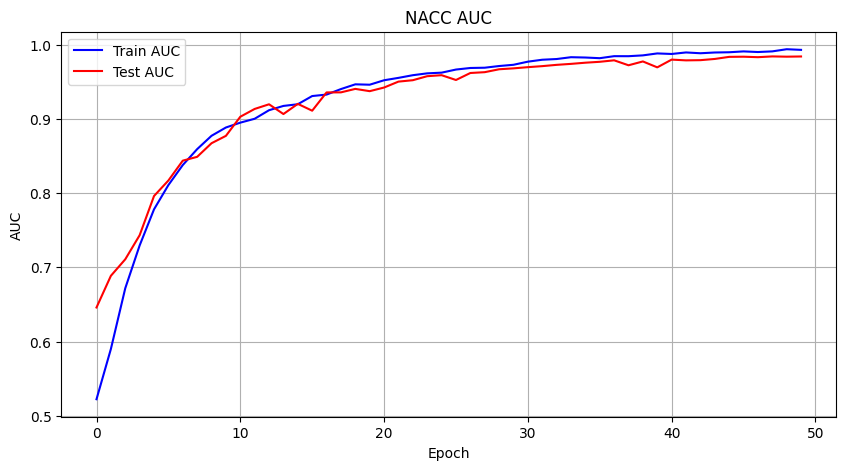

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("NACC AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

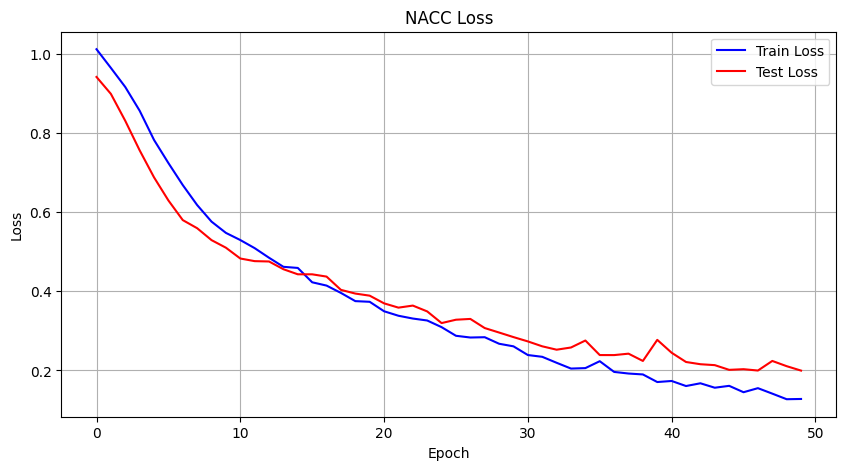

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("NACC Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()